###Bibliotheken einfügen


In [2]:
# import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import wandb

##Vorverarbeitung

In [3]:
# Vorverarbeitung und filtern
df_goldpreis_alles=pd.read_csv('Data/combined_gold_economic_factors_withweekdays.csv', index_col=0, parse_dates=True) # einlesen
df_goldpreis_alles.index = pd.to_datetime(df_goldpreis_alles.index) #Datum umwandeln
df_goldpreis_alles = df_goldpreis_alles[df_goldpreis_alles.index > pd.Timestamp('2021-01-01')] # nach 2021 filtern
df_goldpreis=df_goldpreis_alles['Goldpreis']

# Da Datenpunkte an Wochenenden nicht plausibel sind, wurden sie gelöscht
# print(df_goldpreis.index.dayofweek.value_counts())
df_goldpreis = df_goldpreis[df_goldpreis.index.dayofweek < 5]
print(len(df_goldpreis))


1071


##Vollständigkeitsprüfung. Die Daten liegen erst ab 2021 vollständig vor.

In [4]:
# Die Daten werden auf Vollständigkeit abgeglichen mit allen möglichen Werktagen
# Dazu werden alle Werktage seit 2021 in eine Liste gespeichert
Werktage_seit_2021 = pd.date_range(start='1/1/2021', end='12/05/2025', freq='D')
Werktage_seit_2021 = Werktage_seit_2021[Werktage_seit_2021.dayofweek < 5]
Werktage_seit_2021 = Werktage_seit_2021.normalize()
print(len(Werktage_seit_2021))

# Überprüfung, für welche Werktage keine Daten vorliegen.
counter=0
Fehlwerte=[]
for i in Werktage_seit_2021:
    if i not in df_goldpreis.index.normalize():
        counter += 1
        Fehlwerte.append(i)
        # if i < pd.Timestamp('2021-01-01'):
            # print(i) 
            ## --> 185 Fehlwerte in 2020
            # counter_2020 += 1

print(counter)

# Abgleich mit den Werktagen, an denen die Börse geschlossen war
import pandas_market_calendars as mcal

# NYSE-Kalender laden
nyse = mcal.get_calendar('NYSE')

# Handelszeitplan abrufen (enthält nur Handelstage)
schedule = nyse.schedule(start_date='2021-01-01', end_date='2024-12-31')

richtige_Fehlwerte=[]
falsche_Fehlwerte=[]
for i in Fehlwerte:
    if i not in schedule: 
        richtige_Fehlwerte.append(i)
    elif i in schedule:
        falsche_Fehlwerte.append(i)

print('Fehlwerte an Schließtagen: ' + str(len(richtige_Fehlwerte))) 
print('Wirkliche Fehlwerte: ' + str (len(falsche_Fehlwerte)))

# Fazit: Es liegen für alle Werktage, an denen die Börse geöffnet war, Daten vor.

1286
215
Fehlwerte an Schließtagen: 215
Wirkliche Fehlwerte: 0


###Maximalwertuntersuchung und Outlier Detection 

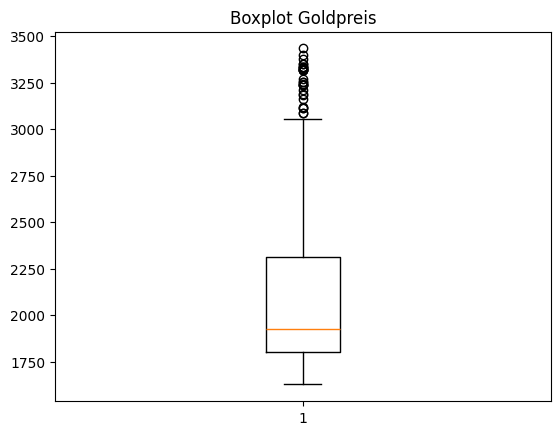

Anzahl an Outliern:30


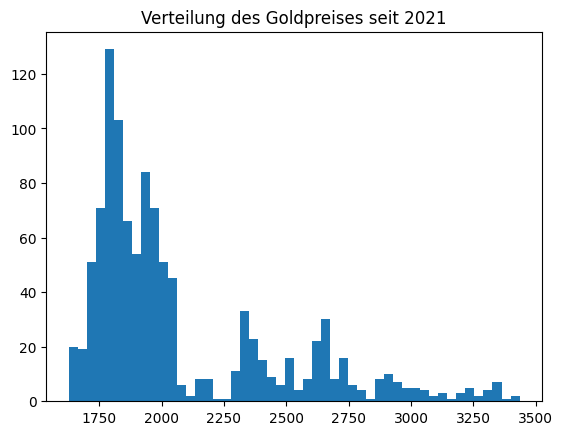

<Figure size 640x480 with 0 Axes>

In [5]:
#Boxplot für Überblick
plt.boxplot(df_goldpreis)
plt.title('Boxplot Goldpreis')
plt.show()
plt.clf()

#Ausreißer finden
def find_outliers_IQR(df):
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   return outliers

print('Anzahl an Outliern:' + str(len(find_outliers_IQR(df_goldpreis))))
# print(find_outliers_IQR(df_goldpreis))
# --> Online Abgleich: nur plausible Werte

plt.title('Verteilung des Goldpreises seit 2021')
plt.hist(df_goldpreis, bins=50)
plt.show()
plt.clf()

##Goldpreis im Zeitverlauf

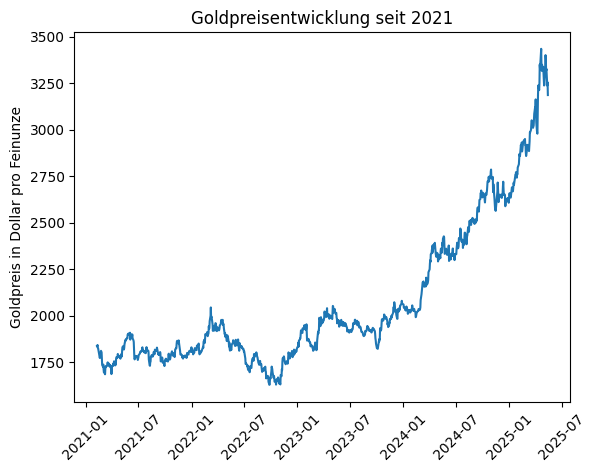

<Figure size 640x480 with 0 Axes>

In [6]:
# Goldpreisentwicklung
ax = plt.subplot(1, 1, 1)
plt.title('Goldpreisentwicklung seit 2021')
plt.plot(df_goldpreis)
plt.ylabel('Goldpreis in Dollar pro Feinunze')
plt.xticks(rotation=45)
plt.show()
plt.clf()

##ACF-PACF Plots

<Figure size 1200x600 with 0 Axes>

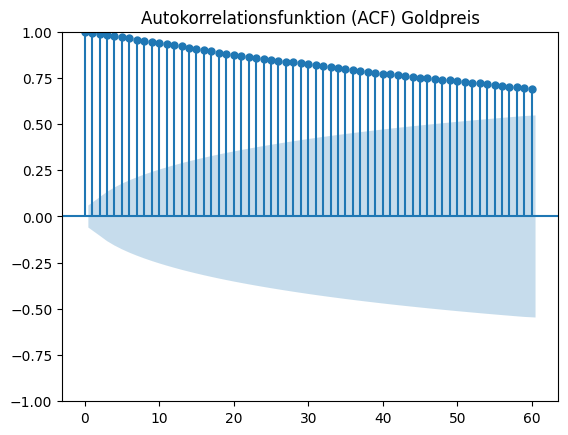

<Figure size 1200x600 with 0 Axes>

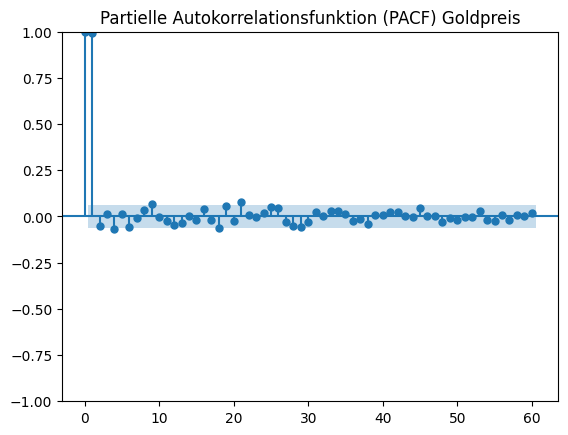

In [7]:
# Plotten der ACF und PACF
plt.figure(figsize=(12, 6))
plot_acf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Autokorrelationsfunktion (ACF) Goldpreis')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Partielle Autokorrelationsfunktion (PACF) Goldpreis')
plt.show()#

##Stationarität prüfen

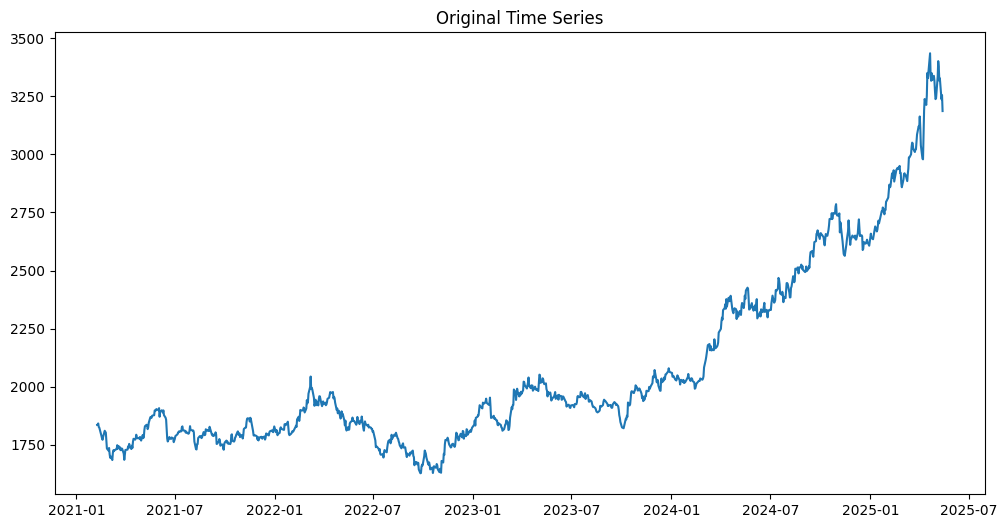

ADF-Test für die ursprüngliche Zeitreihe:
ADF Statistic: -3.095666752874545
p-value: 0.026875534577884684
Critical Values:
	1%: -3.4364762217105844
	5%: -2.8642449457774135
	10%: -2.5682102104987337


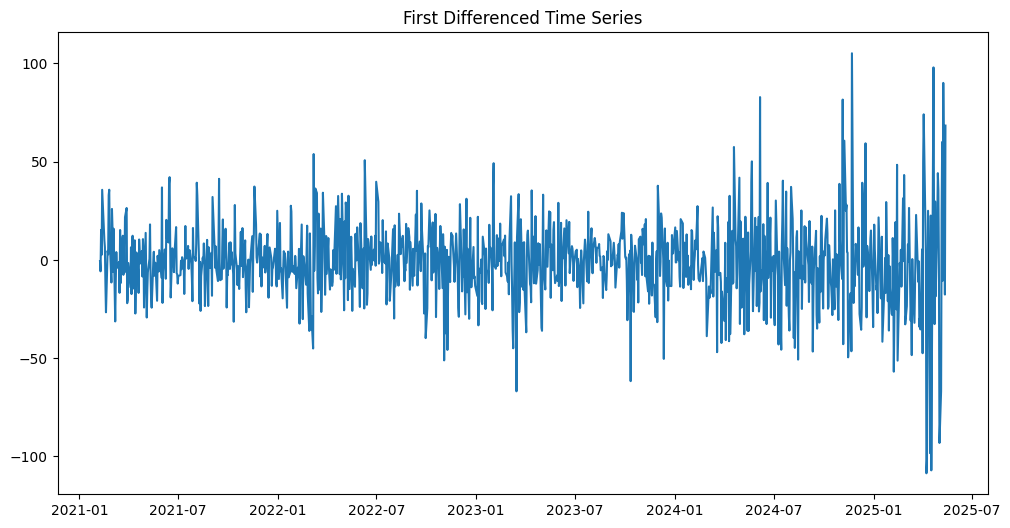


ADF-Test für die erste Differenzierung:
ADF Statistic: -23.450831480921615
p-value: 0.0
Critical Values:
	1%: -3.436487721786906
	5%: -2.8642500182800266
	10%: -2.568212912125293


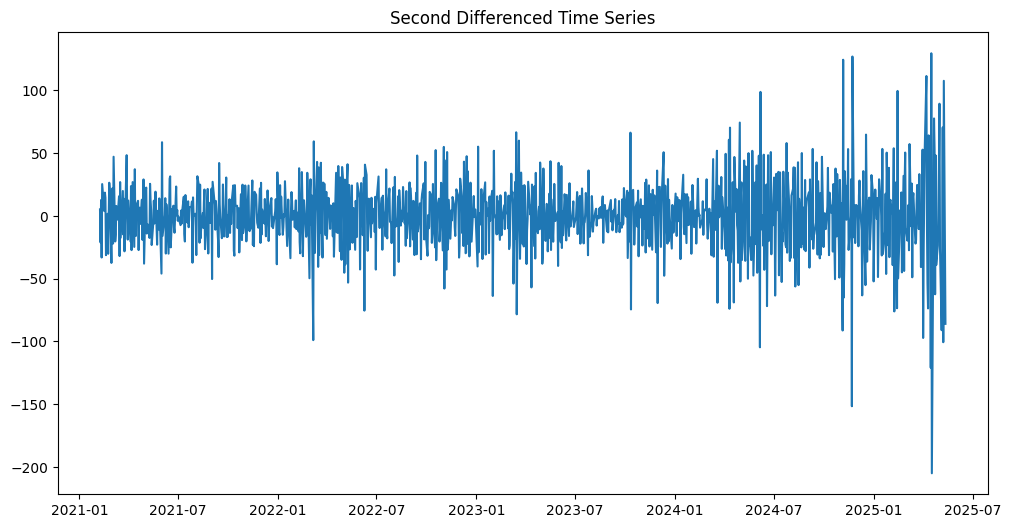


ADF-Test für die zweite Differenzierung:
ADF Statistic: -12.777574402988327
p-value: 7.535822685689218e-24
Critical Values:
	1%: -3.436617132314828
	5%: -2.864307097893787
	10%: -2.568243313067353


<Figure size 1200x600 with 0 Axes>

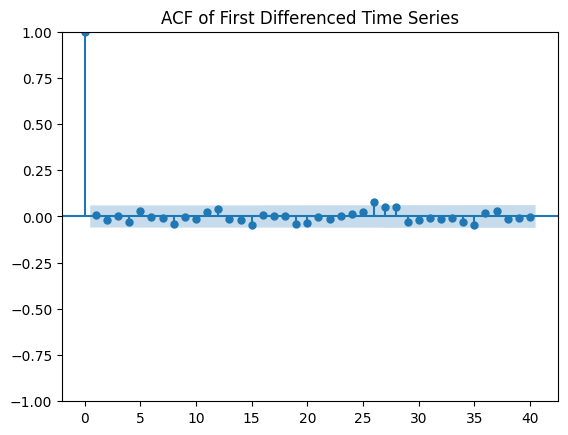

<Figure size 1200x600 with 0 Axes>

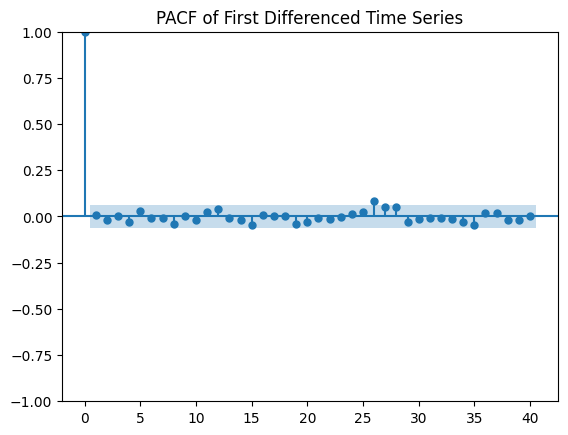

In [8]:
# Funktion zum ADF-Test
def adf_test(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

# Plot der ursprünglichen Zeitreihe
plt.figure(figsize=(12, 6))
plt.plot(df_goldpreis)
plt.title('Original Time Series')
plt.show()

# ADF-Test für die ursprüngliche Zeitreihe
print("ADF-Test für die ursprüngliche Zeitreihe:")
adf_test(df_goldpreis)

# ADF zeigt Stationarität an, aber aus der Analyse ist zu entnehmen, dass es nicht stationär ist

# Erste Differenzierung
first_diff = df_goldpreis.diff().dropna()

# Plot der ersten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(first_diff)
plt.title('First Differenced Time Series')
plt.show()

# ADF-Test für die erste Differenzierung
print("\nADF-Test für die erste Differenzierung:")
adf_test(first_diff)

# Jetzt ist es stationär, aber die Varianz nimmt im Zeitverlauf zu. Daher 2. Differenzierung.

# Zweite Differenzierung
second_diff = first_diff.diff().dropna()

# Plot der zweiten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(second_diff)
plt.title('Second Differenced Time Series')
plt.show()

# ADF-Test für die zweite Differenzierung
print("\nADF-Test für die zweite Differenzierung:")
adf_test(second_diff)

# Plot der ACF und PACF für die differenzierten Zeitreihen
plt.figure(figsize=(12, 6))
plot_acf(first_diff, lags=40, alpha=0.05)
plt.title('ACF of First Differenced Time Series')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(first_diff, lags=40, alpha=0.05)
plt.title('PACF of First Differenced Time Series')
plt.show()

# Fazit: Nach der ersten Differenzierung sind die Daten stationär, aber die Varianz nimmt im Zeitverlauf zu

##Goldpreis nach Wochentagen

   Wochentag    Goldpreis
0          0  2080.608005
1          1  2074.613423
2          2  2069.983227
3          3  2071.310535
4          4  2071.298588


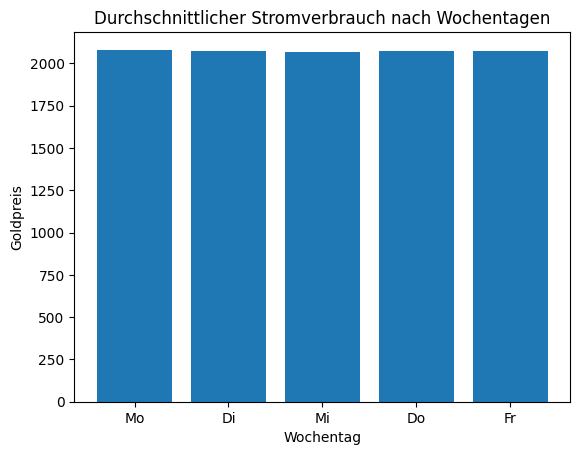

<Figure size 640x480 with 0 Axes>

In [9]:
# Wochentag: Montag = 0 .. Sonntag = 6
# Vorverarbeitung und filtern
df_goldpreis_alles=pd.read_csv('Data/combined_gold_economic_factors_withweekdays.csv', index_col=0, parse_dates=True) # einlesen
df_goldpreis_alles.index = pd.to_datetime(df_goldpreis_alles.index) #Datum umwandeln
df_goldpreis_alles = df_goldpreis_alles[df_goldpreis_alles.index > pd.Timestamp('2021-01-01')] # nach 2021 filtern
df_goldpreis=df_goldpreis_alles['Goldpreis']

# Da Datenpunkte an Wochenenden nicht plausibel sind, wurden sie gelöscht
# print(df_goldpreis.index.dayofweek.value_counts())
df_goldpreis = df_goldpreis[df_goldpreis.index.dayofweek < 5]
df_goldpreis = df_goldpreis.to_frame()

df_goldpreis['Wochentag'] = df_goldpreis.index.weekday

#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_weekday = df_goldpreis.groupby('Wochentag')['Goldpreis'].mean().reset_index()
print(mean_per_weekday)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis'])
plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
plt.xlabel('Wochentag')
plt.ylabel('Goldpreis')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr'])
plt.show()
plt.clf()

##Goldpreis nach Monat
##Innerhalb von kürzerem Zeitraum oder vgl. mit Wochenmittel

    Monat    Goldpreis
0       1  2114.999383
1       2  2102.393846
2       3  2132.356955
3       4  2260.336553
4       5  2150.843737
5       6  1974.532892
6       7  1980.210241
7       8  1981.917389
8       9  1979.858049
9      10  2032.241395
10     11  2038.964578
11     12  2063.628988


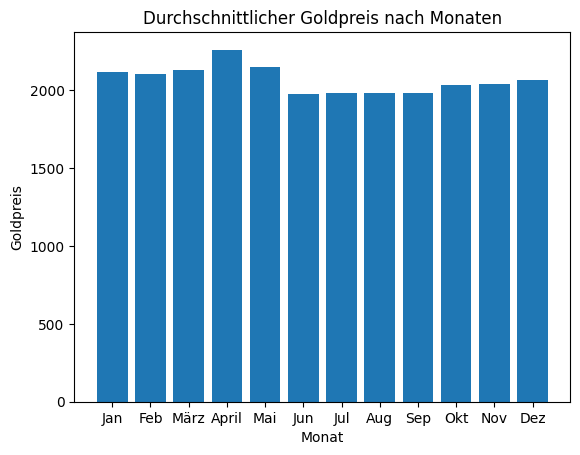

<Figure size 640x480 with 0 Axes>

In [10]:
# Wochentag: Montag = 0 .. Sonntag = 6
df_goldpreis['Monat'] = df_goldpreis.index.month
#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_month = df_goldpreis.groupby('Monat')['Goldpreis'].mean().reset_index()
mean_months = mean_per_month['Goldpreis'].mean()
# mean_per_weekday.loc[len(mean_per_weekday.index)] = [7, mean_weekdays]
print(mean_per_month)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_month['Monat'], mean_per_month['Goldpreis'])
plt.title('Durchschnittlicher Goldpreis nach Monaten')
plt.xlabel('Monat')
plt.ylabel('Goldpreis')
ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
ax.set_xticklabels(['Jan', 'Feb', 'März', 'April', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
plt.show()
plt.clf()

# Monate, die bereits vergangen sind, haben höhere Werte

##Goldpreis nach Wochentag und Monat

Januar
   Wochentag    Goldpreis
0          0  2084.483846
1          1  2100.190556
2          2  2111.376765
3          3  2118.178438
4          4  2154.645294


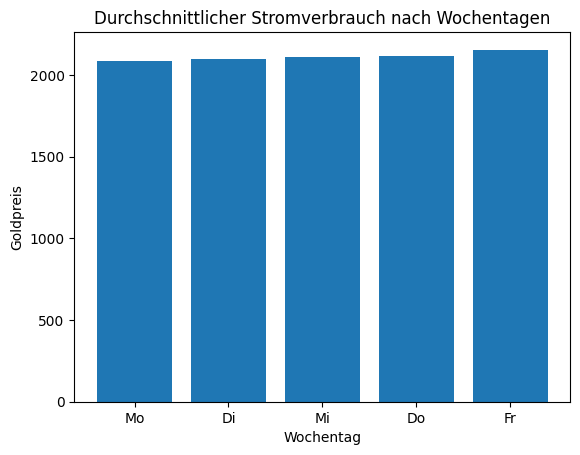

Februar
   Wochentag    Goldpreis
0          0  2110.240000
1          1  2098.537368
2          2  2108.210789
3          3  2100.633250
4          4  2096.505263


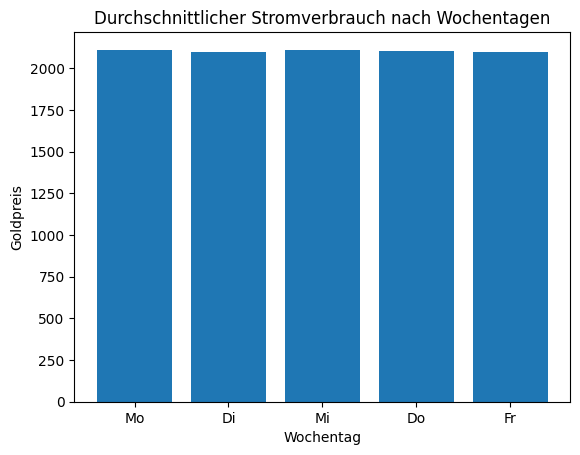

März
   Wochentag    Goldpreis
0          0  2165.287273
1          1  2112.497500
2          2  2109.005652
3          3  2133.983636
4          4  2142.534762


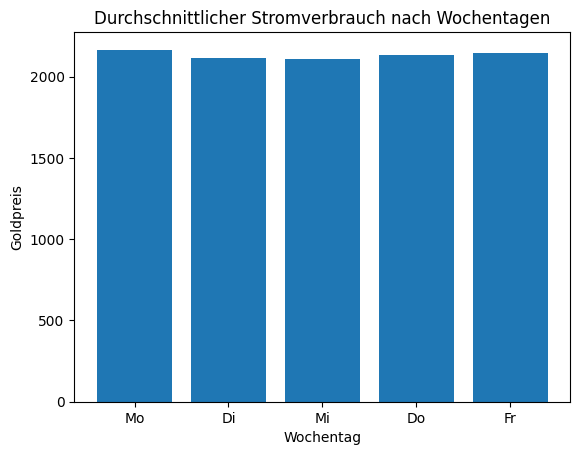

April
   Wochentag    Goldpreis
0          0  2254.534048
1          1  2293.186136
2          2  2301.218571
3          3  2235.676190
4          4  2208.031389


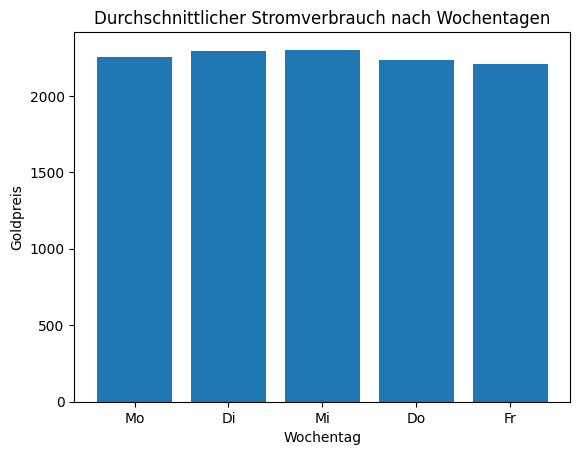

Mai
   Wochentag    Goldpreis
0          0  2142.503529
1          1  2134.393500
2          2  2154.228250
3          3  2159.340000
4          4  2163.563158


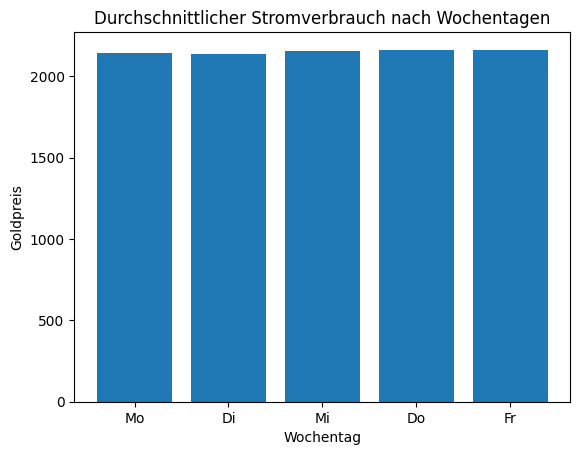

Juni
   Wochentag    Goldpreis
0          0  1997.714643
1          1  1973.955294
2          2  1944.572941
3          3  1978.516944
4          4  1981.761176


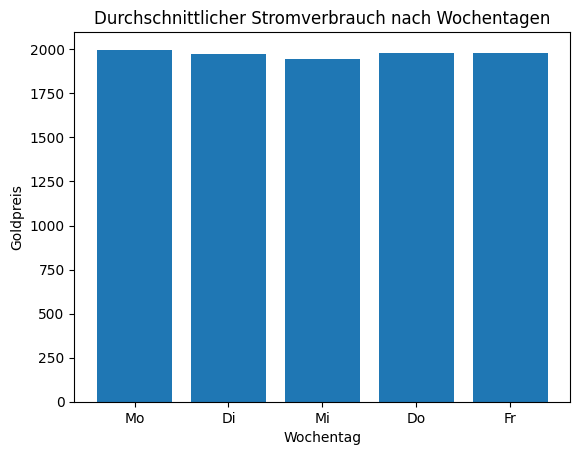

Juli
   Wochentag    Goldpreis
0          0  2011.968750
1          1  1999.778750
2          2  2000.629118
3          3  1936.639062
4          4  1954.031667


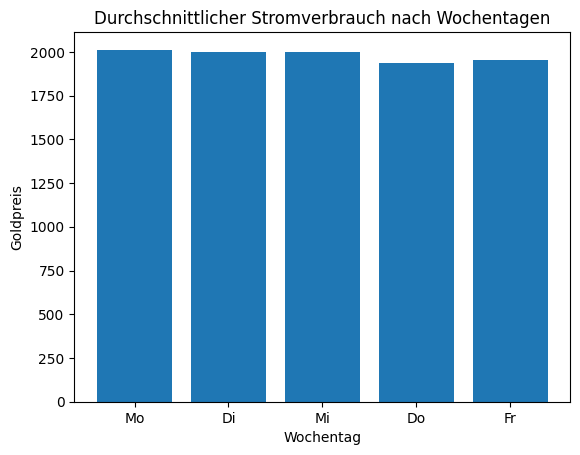

August
   Wochentag    Goldpreis
0          0  1962.352222
1          1  1960.070789
2          2  1965.994722
3          3  2008.768889
4          4  2015.478529


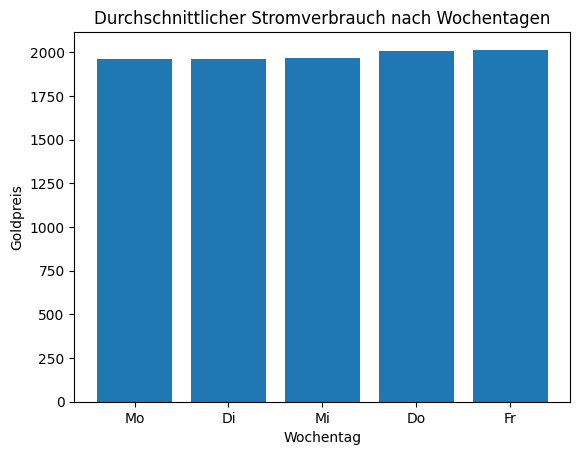

September
   Wochentag    Goldpreis
0          0  2035.643462
1          1  1983.020937
2          2  1969.994706
3          3  1956.699722
4          4  1969.230833


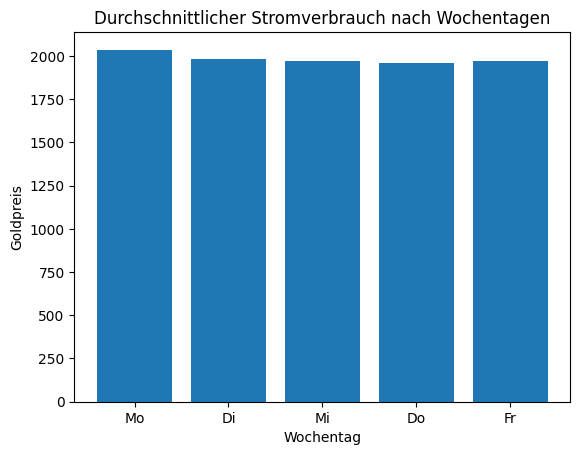

Oktober
   Wochentag    Goldpreis
0          0  1985.286389
1          1  2044.817778
2          2  2053.262059
3          3  2080.606563
4          4  2002.101471


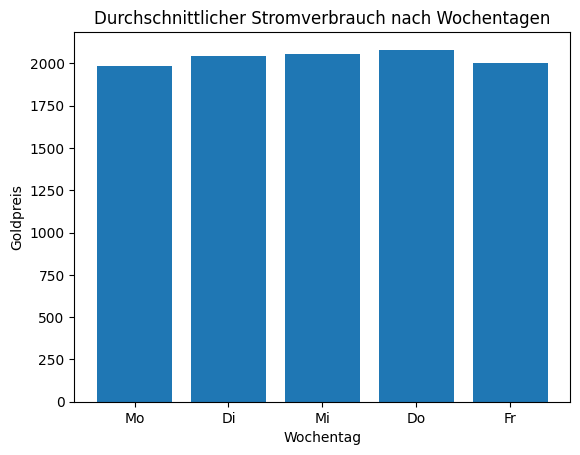

November
   Wochentag    Goldpreis
0          0  2029.551176
1          1  2013.548333
2          2  2021.013056
3          3  2043.563462
4          4  2090.780000


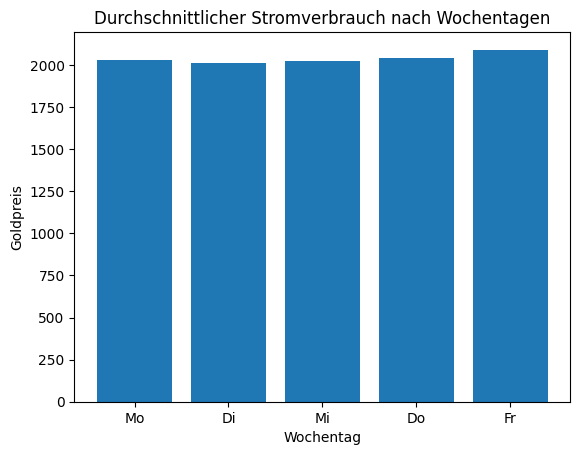

Dezember
   Wochentag    Goldpreis
0          0  2115.460333
1          1  2100.097647
2          2  2018.729687
3          3  2037.219444
4          4  2052.313611


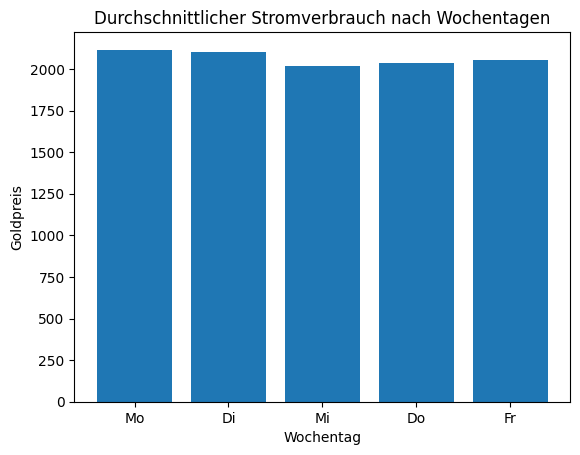

<Figure size 640x480 with 0 Axes>

In [11]:
def Balkendiagramm_Wochentag(data, Monat):
    data = data[data['Monat'] == Monat]
    mean_per_weekday = data.groupby('Wochentag')['Goldpreis'].mean().reset_index()
    print(mean_per_weekday)

    # Balkendiagramm erstellen
    ax = plt.subplot(1,1,1)
    plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis'])
    plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
    plt.xlabel('Wochentag')
    plt.ylabel('Goldpreis')
    ax.set_xticks([0, 1, 2, 3, 4]) 
    ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr'])
    plt.show()
    plt.clf()

Mon = ['Januar', 'Februar', 'März', 'April', 'Mai', 'Juni', 'Juli', 'August', 'September', 'Oktober', 'November', 'Dezember']
Monate = range(1, 13)

for month, Monat in zip(Mon, Monate):
    print(month)
    Balkendiagramm_Wochentag(df_goldpreis, Monat)

##ARIMA Modell mit Train-/Test Split

MSE für den Goldpreis: 84148.0650837248


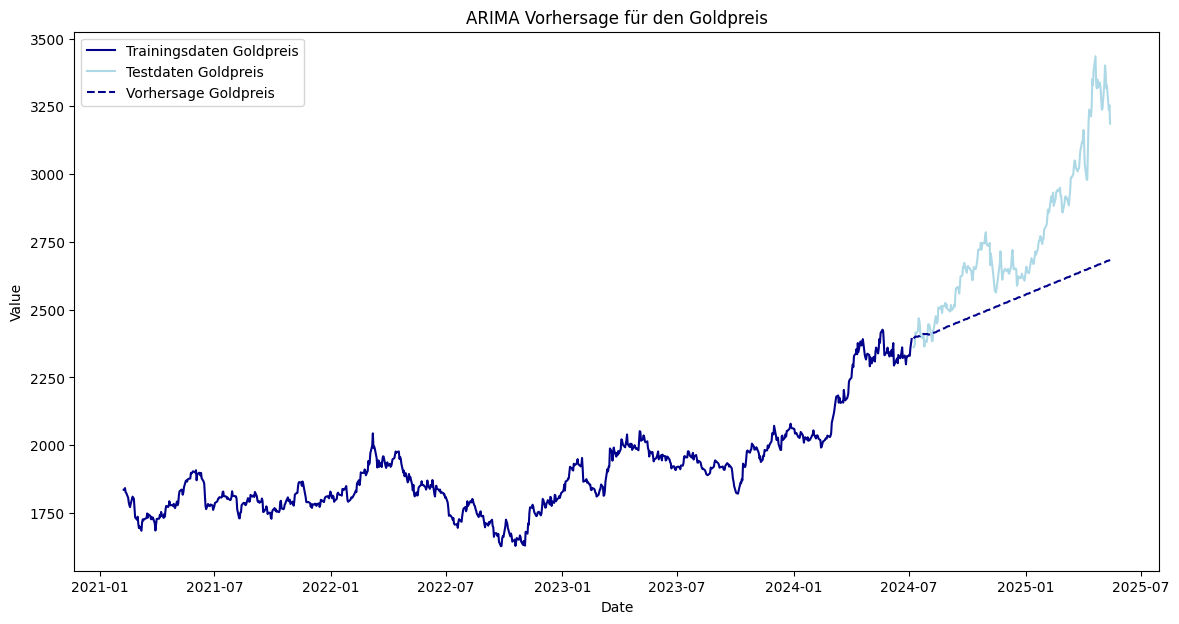

In [12]:
df_goldpreis = df_goldpreis.sort_index()
df_goldpreis = df_goldpreis.asfreq('B')
df_goldpreis = df_goldpreis.interpolate(method='linear')
df_goldpreis.index.freq = 'B'


# Aufteilen in Trainingsdaten und Testdaten
train_size = int(0.8 * len(df_goldpreis))
train, test = df_goldpreis[:train_size], df_goldpreis[train_size:]

# ARIMA Modell fitten
arima_model_Goldpreis = ARIMA(train['Goldpreis'], order=(20, 2, 1))
arima_model_Goldpreis_fit = arima_model_Goldpreis.fit()

# Vorhersage für die Testdaten
arima_forecast_Goldpreis = arima_model_Goldpreis_fit.forecast(steps=len(test))

# MSE berechnen
mse_Goldpreis = mean_squared_error(test['Goldpreis'], arima_forecast_Goldpreis)

# Ergebnisse anzeigen
print(f'MSE für den Goldpreis: {mse_Goldpreis}')


# Plot für die Vorhersage des Goldpreises
plt.figure(figsize=(14, 7))
plt.plot(train['Goldpreis'], color='darkblue', label='Trainingsdaten Goldpreis')
plt.plot(test.index, test['Goldpreis'], color='lightblue', label='Testdaten Goldpreis')
plt.plot(test.index, arima_forecast_Goldpreis, color='darkblue', linestyle='--', label='Vorhersage Goldpreis')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('ARIMA Vorhersage für den Goldpreis')
plt.legend()
plt.show()

##Hyperparameter Tuning

In [13]:
# Sweep konfigurieren

# Methode: Zufälliges probieren (random)
sweep_config = {'method': 'random'}

# Ziel ist es den MSE zu minimieren
metric = { 'name': 'MSE', 'goal': 'minimize'}
sweep_config['metric'] = metric

# Parameter, die ausprobiert werden sollen
parameters_dict = {
    'p': {
        'values': [1, 2, 3, 4, 5, 6, 20, 40]
    },
    'd': {
        'values': [1, 2]
    },
    'q': {
        'values': [1, 2, 3, 4, 5, 6, 20, 40]
    }
}

sweep_config['parameters'] = parameters_dict

sweep_id = wandb.sweep(sweep_config)

# Vorverarbeitung für den Sweep
df_goldpreis = df_goldpreis.sort_index()
df_goldpreis = df_goldpreis.asfreq('B')
df_goldpreis = df_goldpreis.interpolate(method='linear')
df_goldpreis.index.freq = 'B'

# Aufteilen in Trainingsdaten und Testdaten
train_size = int(0.8 * len(df_goldpreis))
train, test = df_goldpreis[:train_size], df_goldpreis[train_size:]

# Trainingsfunktion ARIMA mit Wandb-Sweep
def training():
    wandb.init()
    order = (wandb.config.p, wandb.config.d, wandb.config.q)
    global train, test
    
    # ARIMA Modell fitten
    arima_model_Goldpreis = ARIMA(train['Goldpreis'], order=(order))
    arima_model_Goldpreis_fit = arima_model_Goldpreis.fit()

    # Vorhersage für die Testdaten
    arima_forecast_Goldpreis = arima_model_Goldpreis_fit.forecast(steps=len(test))

    # MSE berechnen
    mse_Goldpreis = mean_squared_error(test['Goldpreis'], arima_forecast_Goldpreis)
    
    wandb.log({"MSE": mse_Goldpreis})
    
    # Ergebnisse anzeigen
    print(f'MSE für den Goldpreis: {mse_Goldpreis}')

# Sweep Starten
wandb.agent(sweep_id, function=training, count=30)  # z.B. 10 Runs

# Beste gefundene Konfiguration p=20, d=2, q=1
# https://wandb.ai/johannes-johannes-anhalt-university-of-applied-sciences/uncategorized/sweeps/689cfxkc?nw=nwuserjohannesjohannes

Create sweep with ID: ooz5hb1n
Sweep URL: https://wandb.ai/johannes-johannes-anhalt-university-of-applied-sciences/uncategorized/sweeps/ooz5hb1n


wandb: Agent Starting Run: tlyrd9wt with config:
wandb: 	d: 1
wandb: 	p: 5
wandb: 	q: 4
wandb: Currently logged in as: johannes-johannes (johannes-johannes-anhalt-university-of-applied-sciences) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


C:\Users\johan\PycharmProjects\data-mining\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\johan\PycharmProjects\data-mining\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\johan\PycharmProjects\data-mining\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE für den Goldpreis: 200946.91855385853


MSE,▁
MSE,200946.91855


wandb: Agent Starting Run: 9trtgp5e with config:
wandb: 	d: 1
wandb: 	p: 40
wandb: 	q: 4


C:\Users\johan\PycharmProjects\data-mining\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MSE für den Goldpreis: 204092.06867440947


MSE,▁
MSE,204092.06867


wandb: Ctrl + C detected. Stopping sweep.


### Vorhersage für 1 Woche mit den aktuellen Daten

In [22]:
import requests

# Dein API-Schlüssel von Alpha Vantage
api_key = 'JX03FK2W87N81TEN'

# API-Endpunkt für den täglichen Goldpreis (XAU/USD)
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=XAUUSD&apikey={api_key}&outputsize=full'

 # API-Anfrage senden
response = requests.get(url)
data = response.json()

# Die historischen Daten aus der Antwort extrahieren
if "Time Series (Daily)" in data:   
    time_series = data["Time Series (Daily)"]

# Die Daten in ein pandas DataFrame umwandeln
    df = pd.DataFrame.from_dict(time_series, orient='index')
    df = df.astype(float)  # Umwandeln der Daten in numerische Werte
    df.index = pd.to_datetime(df.index)  # Index als Datum umwandeln

# Ausgabe der ersten Zeilen des DataFrames
    print(df.head())
    print(len(df))
    print(df.index.min())  # Ältestes Datum
    print(df.index.max())  # Neuestes Datum

else:
    print("Fehlerhafte API-Antwort:")
    print(data)
    
# Speichern der Daten als CSV-Datei
# df.to_csv('gold_prices.csv')
# print('Daten wurden erfolgreich als CSV gespeichert.')

df_goldpreis=df['4. close']

# Da Datenpunkte an Wochenenden nicht plausibel sind, wurden sie gelöscht
# print(df_goldpreis.index.dayofweek.value_counts())
df_goldpreis = df_goldpreis[df_goldpreis.index.dayofweek < 5]
print(len(df_goldpreis))

df_goldpreis = df_goldpreis.sort_index()
df_goldpreis = df_goldpreis.asfreq('B')
df_goldpreis = df_goldpreis.interpolate(method='linear')
df_goldpreis.index.freq = 'B'


# ARIMA Modell fitten
arima_model_Goldpreis = ARIMA(df_goldpreis, order=(20, 2, 1))
arima_model_Goldpreis_fit = arima_model_Goldpreis.fit()

# Vorhersage für die Testdaten
arima_forecast_Goldpreis = arima_model_Goldpreis_fit.forecast(steps=6)

print(arima_forecast_Goldpreis)

# Series in DataFrame umwandeln
forecast_df = arima_forecast_Goldpreis.reset_index()
forecast_df.columns = ['Datum', 'Prognose']

# Speichern als CSV
forecast_df.to_csv('Goldpreis_Vorhersage.csv', index=False)
print("Vorhersage erfolgreich gespeichert.")


            1. open  2. high   3. low  4. close  5. volume
2025-06-05  3378.20  3384.19  3368.35   3368.95        0.0
2025-06-04  3360.06  3384.72  3343.85   3378.21        0.0
2025-06-03  3387.45  3388.70  3333.26   3360.03        0.0
2025-06-02  3310.28  3392.27  3301.57   3387.48        0.0
2025-06-01  3298.90  3316.73  3295.53   3310.31        0.0
1640
2019-01-28 00:00:00
2025-06-05 00:00:00
1376


C:\Users\johan\PycharmProjects\data-mining\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


2025-06-06    3396.616636
2025-06-09    3387.128125
2025-06-10    3367.083514
2025-06-11    3345.433985
2025-06-12    3353.503833
2025-06-13    3364.518257
Freq: B, Name: predicted_mean, dtype: float64
Vorhersage erfolgreich gespeichert.
